In [1]:
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import MultipleHarmonicTimeFrequencyWaveform

In [2]:
# Define the parameters for the time-frequency grid
dT = 86400 / 4  # 6 hours # SFT time.
nT = 365 * 4  # 1 year # Number of SFT time bins in the total observation
dt = 5  # time step for the *time-domain* data -> used to determine fmax for the SFT
dF = 1 / dT  # Frequency spacing within the SFT.
# 1/(2*dt) is the Nyquist frequency for the time-domain data
fmax = 1 / (2 * dt)  # Nyquist frequency for the time-domain data

nF = (
    int((fmax) / dF) + 1
)  # Number of frequency bins needed to cover the Nyquist frequency.

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 10,  # Number of frequency bins to use in the fresnel kernel
}

In [3]:
generator = MultipleHarmonicTimeFrequencyWaveform(config, backend="gpu")

Spacecraft light travel times not supplied. Falling back to analytic calculation


In [4]:
nsrc = 1
n_modes = 10

amplitudes = cp.ones(
    (nsrc, n_modes, nT), dtype=cp.float64
)  # shape (n_sources, n_modes, nT)

fr0 = 1e-3
fdot0 = 1e-10

t_evol = generator.t_tranche + dT / 2

phase_evolutions = (
    2
    * cp.pi
    * (fr0 * t_evol + 0.5 * fdot0 * t_evol**2)[None, :]
    * cp.arange(1, n_modes + 1)[:, None]
)[None, ...]  # shape (n_sources, n_modes, nT)
frequency_evolutions = (fr0 + fdot0 * t_evol)[None, :] * cp.arange(
    1, n_modes + 1
)[:, None][None, ...]  # shape (n_sources, n_modes, nT)
fdot_evolutions = cp.tile(fdot0 * cp.arange(1, n_modes + 1)[:, None], (1, nT))[
    None, ...
]  # shape (n_sources, n_modes, nT)

phase_evolutions = cp.tile(phase_evolutions, (nsrc, 1, 1))
frequency_evolutions = cp.tile(frequency_evolutions, (nsrc, 1, 1))
fdot_evolutions = cp.tile(fdot_evolutions, (nsrc, 1, 1))

all_inputs = cp.stack(
    [amplitudes, phase_evolutions, frequency_evolutions, fdot_evolutions],
    dtype=cp.float64,
).transpose(1, 2, 3, 0)  # shape (4, n_sources, n_modes, nT)

In [5]:
all_inputs.shape

(1, 10, 1460, 4)

In [6]:
tf = generator(all_inputs)
tf.get()

/scratch/cchapmanbird/packages/ukgs/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


array([[[[ 0. +0.j,  0. +0.j],
         [nan+nanj, nan+nanj],
         [nan+nanj, nan+nanj],
         ...,
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j]],

        [[ 0. +0.j,  0. +0.j],
         [nan+nanj, nan+nanj],
         [nan+nanj, nan+nanj],
         ...,
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j]],

        [[ 0. +0.j,  0. +0.j],
         [nan+nanj, nan+nanj],
         [nan+nanj, nan+nanj],
         ...,
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j]],

        ...,

        [[ 0. +0.j,  0. +0.j],
         [nan+nanj, nan+nanj],
         [nan+nanj, nan+nanj],
         ...,
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j]],

        [[ 0. +0.j,  0. +0.j],
         [nan+nanj, nan+nanj],
         [nan+nanj, nan+nanj],
         ...,
         [ 0. +0.j,  0. +0.j],
         [ 0. +0.j,  0. +0.j],
         

In [7]:
tf.shape

(1, 1460, 2161, 2)

Text(0, 0.5, 'Frequency (Hz)')

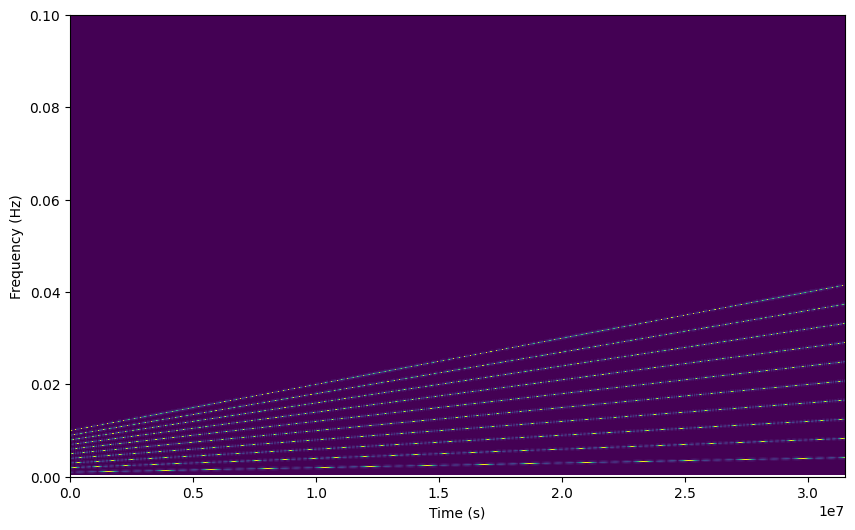

In [8]:
plt.figure(figsize=(10, 6))
plt.pcolormesh(
    generator.t_tranche.get(),
    generator.f_tranche.get(),
    np.abs((tf[0, :, :, 0]).T.get()),
)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

In [9]:
psd_tmp = cp.ones((nT, nF, 2), dtype=cp.float64)  # * 1e-34

In [11]:
nsrc = 10000
n_modes = 10

amplitudes = cp.ones(
    (nsrc, n_modes, nT), dtype=cp.float64
)  # shape (n_sources, n_modes, nT)

fr0 = 1e-3
fdot0 = 1e-10

t_evol = generator.t_tranche + dT / 2

phase_evolutions = (
    2
    * cp.pi
    * (fr0 * t_evol + 0.5 * fdot0 * t_evol**2)[None, :]
    * cp.arange(1, n_modes + 1)[:, None]
)[None, ...]  # shape (n_sources, n_modes, nT)
frequency_evolutions = (fr0 + fdot0 * t_evol)[None, :] * cp.arange(
    1, n_modes + 1
)[:, None][None, ...]  # shape (n_sources, n_modes, nT)
fdot_evolutions = cp.tile(fdot0 * cp.arange(1, n_modes + 1)[:, None], (1, nT))[
    None, ...
]  # shape (n_sources, n_modes, nT)

phase_evolutions = cp.tile(phase_evolutions, (nsrc, 1, 1))
frequency_evolutions = cp.tile(frequency_evolutions, (nsrc, 1, 1))
fdot_evolutions = cp.tile(fdot_evolutions, (nsrc, 1, 1))

all_inputs = cp.stack(
    [amplitudes, phase_evolutions, frequency_evolutions, fdot_evolutions],
    dtype=cp.float64,
).transpose(1, 2, 3, 0)  # shape (4, n_sources, n_modes, nT)


def blah():
    return generator(
        all_inputs, compute_statistic=True, channels=tf[0], psds=psd_tmp
    )  # .get()
    cp.cuda.runtime.deviceSynchronize()


tf_stat = blah()

In [29]:
tf_stat.shape

(10000, 10, 1460, 2)

In [12]:
%timeit blah()

403 ms ± 1.12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


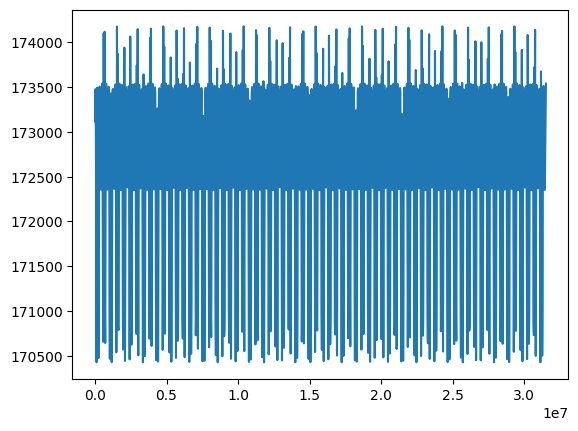

In [28]:
plt.plot(
    generator.t_tranche.get(), np.abs(tf_stat[0, 0, :, 0].get()), label="d_h"
)